In [1]:
%matplotlib inline

%load_ext autoreload
%autoreload 2

In [2]:
from os.path import exists
import sys
sys.path.append('..')

In [3]:
from loguru import logger
import numpy as np
from stable_baselines3.common.env_checker import check_env

# Sequential DDA environment test

In [4]:
from vimms.Common import POSITIVE, load_obj, save_obj
from vimms.ChemicalSamplers import MZMLFormulaSampler, MZMLRTandIntensitySampler, MZMLChromatogramSampler

from vimms_gym.env import DDAEnv
from vimms_gym.chemicals import generate_chemicals
from vimms_gym.features import obs_to_dfs

In [5]:
n_chemicals = (5000, 20000)
mz_range = (70, 1000)
rt_range = (0, 1440)
intensity_range = (1E4, 1E20)

In [6]:
min_mz = mz_range[0]
max_mz = mz_range[1]
min_rt = rt_range[0]
max_rt = rt_range[1]
min_log_intensity = np.log(intensity_range[0])
max_log_intensity = np.log(intensity_range[1])

In [7]:
isolation_window = 0.7
N = 10
rt_tol = 15
mz_tol = 10
min_ms1_intensity = 5000
ionisation_mode = POSITIVE

enable_spike_noise = True
noise_density = 0.1
noise_max_val = 1E3

In [8]:
mzml_filename = 'fullscan_QCB.mzML'    
samplers = None
samplers_pickle = 'samplers_%s.p' % mzml_filename
if exists(samplers_pickle):
    logger.info('Loaded %s' % samplers_pickle)
    samplers = load_obj(samplers_pickle)
    mz_sampler = samplers['mz']
    ri_sampler = samplers['rt_intensity']
    cr_sampler = samplers['chromatogram']
else:    
    logger.info('Creating samplers from %s' % mzml_filename)
    mz_sampler = MZMLFormulaSampler(mzml_filename, min_mz=min_mz, max_mz=max_mz)
    ri_sampler = MZMLRTandIntensitySampler(mzml_filename, min_rt=min_rt, max_rt=max_rt,
                                           min_log_intensity=min_log_intensity,
                                           max_log_intensity=max_log_intensity)
    cr_sampler = MZMLChromatogramSampler(mzml_filename)
    samplers = {
        'mz': mz_sampler,
        'rt_intensity': ri_sampler,
        'chromatogram': cr_sampler
    }
    save_obj(samplers, samplers_pickle)

2022-04-04 23:22:27.306 | INFO     | __main__:<cell line: 4>:5 - Loaded samplers_fullscan_QCB.mzML.p


In [9]:
params = {
    'chemical_creator': {
        'mz_range': mz_range,
        'rt_range': rt_range,
        'intensity_range': intensity_range,
        'n_chemicals': n_chemicals,
        'mz_sampler': mz_sampler,
        'ri_sampler': ri_sampler,
        'cr_sampler': cr_sampler,
    },
    'noise': {
        'enable_spike_noise': enable_spike_noise,
        'noise_density': noise_density,
        'noise_max_val': noise_max_val,
        'mz_range': mz_range
    },
    'env': {
        'ionisation_mode': ionisation_mode,
        'rt_range': rt_range,
        'isolation_window': isolation_window,
        'mz_tol': mz_tol,
        'rt_tol': rt_tol,
    }
}

Initialise a new DDA environment that tracks the top most intense peaks.

In [10]:
max_peaks = 100
env = DDAEnv(max_peaks, params)
check_env(env)

Generate an initial observation (MS1 scan)

In [11]:
observation = env.reset()
scan_df, count_df = obs_to_dfs(observation, env.features)
scan_df, count_df

(    intensities  fragmented  excluded  log_intensities
 0      0.149921         0.0       0.0         6.904131
 1      0.149701         0.0       0.0         6.893991
 2      0.149436         0.0       0.0         6.881784
 3      0.149379         0.0       0.0         6.879153
 4      0.149279         0.0       0.0         6.874530
 ..          ...         ...       ...              ...
 95     0.000000         0.0       0.0         0.000000
 96     0.000000         0.0       0.0         0.000000
 97     0.000000         0.0       0.0         0.000000
 98     0.000000         0.0       0.0         0.000000
 99     0.000000         0.0       0.0         0.000000
 
 [100 rows x 4 columns],
                               counts
 ms_level                      1.0000
 fragmented_count              0.0000
 unfragmented_count            1.0000
 excluded_count                0.0000
 unexcluded_count              1.0000
 elapsed_scans_since_start     0.0001
 elapsed_scans_since_last_ms1  0.00

In [12]:
observation['valid_actions']

array([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 0., 0., 0., 0., 0., 0., 0., 1.],
      dtype=float32)

In [13]:
env.features

[mz=154.12137301791972 rt=0 intensity=996.3823901049237 (0.14992130216422697),
 mz=676.6739652960144 rt=0 intensity=986.3297091833064 (0.14970110573405004),
 mz=648.6435494060386 rt=0 intensity=974.3627459763346 (0.14943603353423668),
 mz=635.6965225057996 rt=0 intensity=971.8029656681601 (0.14937891100365497),
 mz=628.6736629635739 rt=0 intensity=967.321051579489 (0.14927853196621935),
 mz=854.9325566537939 rt=0 intensity=953.8618404407356 (0.14897427375200714),
 mz=547.3736999782637 rt=0 intensity=953.185777507739 (0.14895887768057417),
 mz=603.4841413076382 rt=0 intensity=951.3679254911046 (0.14891742527425744),
 mz=848.7589743776816 rt=0 intensity=950.596551738656 (0.14889981172854974),
 mz=897.8666100356869 rt=0 intensity=943.8481210952796 (0.14874510578074407),
 mz=944.0304942502239 rt=0 intensity=911.7597812536585 (0.14799402155359334),
 mz=863.9185728599837 rt=0 intensity=878.153978890483 (0.14717853367225905),
 mz=468.32177484164055 rt=0 intensity=876.5165726265091 (0.14713800

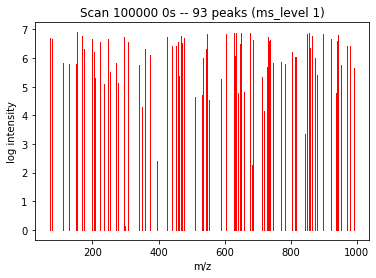

In [14]:
env.render()

Generate 100 ms1 scans

In [15]:
for i in range(200):
    action = max_peaks # ms1
    observation, reward, done, info = env.step(action)

print('reward', reward)
print('done', done)
scan_df, count_df = obs_to_dfs(observation, env.features)
scan_df, count_df

reward -0.1
done False


(    intensities  fragmented  excluded  log_intensities
 0      0.210734         0.0       0.0         9.704642
 1      0.199052         0.0       0.0         9.166694
 2      0.149960         0.0       0.0         6.905936
 3      0.149224         0.0       0.0         6.872039
 4      0.149224         0.0       0.0         6.872036
 ..          ...         ...       ...              ...
 95     0.000000         0.0       0.0         0.000000
 96     0.000000         0.0       0.0         0.000000
 97     0.000000         0.0       0.0         0.000000
 98     0.000000         0.0       0.0         0.000000
 99     0.000000         0.0       0.0         0.000000
 
 [100 rows x 4 columns],
                               counts
 ms_level                      1.0000
 fragmented_count              0.0000
 unfragmented_count            1.0000
 excluded_count                0.0000
 unexcluded_count              1.0000
 elapsed_scans_since_start     0.0201
 elapsed_scans_since_last_ms1  0.00

In [16]:
observation['valid_actions']

array([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 0., 0., 0., 0., 0., 1.],
      dtype=float32)

In [17]:
env.features

[mz=258.4969947671568 rt=80.00000000000006 intensity=16393.53441509632 (0.21073362983682917),
 mz=212.1692703784082 rt=80.00000000000006 intensity=9572.925483394827 (0.19905223391674196),
 mz=203.3435575785719 rt=80.00000000000006 intensity=998.1822232098187 (0.14996049155888208),
 mz=131.61646215107575 rt=80.00000000000006 intensity=964.9144493337008 (0.14922444049468603),
 mz=730.6292779987937 rt=80.00000000000006 intensity=964.9114459916555 (0.14922437290647092),
 mz=833.3944482780043 rt=80.00000000000006 intensity=931.5653551458438 (0.14846066643899067),
 mz=265.4623012097584 rt=80.00000000000006 intensity=916.8899229709659 (0.14811585998329171),
 mz=952.0482781416174 rt=80.00000000000006 intensity=914.3175706727934 (0.14805485328976825),
 mz=770.0441686487587 rt=80.00000000000006 intensity=900.3795408531018 (0.14772128090263298),
 mz=114.95871491960997 rt=80.00000000000006 intensity=896.5061430908033 (0.14762766349029752),
 mz=628.1012851356945 rt=80.00000000000006 intensity=895.4

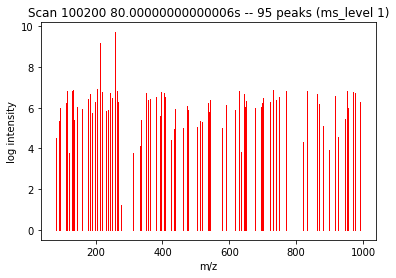

In [18]:
env.render()

Target the most intense precursor for fragmentation, and generate an MS2 scan from that

In [19]:
action = 0
observation, reward, done, info = env.step(action)

print('reward', reward)
print('done', done)
scan_df, count_df = obs_to_dfs(observation, env.features)
scan_df, count_df

reward 0.2695381927896132
done False


(    intensities  fragmented  excluded  log_intensities
 0      0.210734         0.2  0.026667         9.704642
 1      0.199052         0.0  0.000000         9.166694
 2      0.149960         0.0  0.000000         6.905936
 3      0.149224         0.0  0.000000         6.872039
 4      0.149224         0.0  0.000000         6.872036
 ..          ...         ...       ...              ...
 95     0.000000         0.0  0.000000         0.000000
 96     0.000000         0.0  0.000000         0.000000
 97     0.000000         0.0  0.000000         0.000000
 98     0.000000         0.0  0.000000         0.000000
 99     0.000000         0.0  0.000000         0.000000
 
 [100 rows x 4 columns],
                               counts
 ms_level                      2.0000
 fragmented_count              0.0100
 unfragmented_count            0.9900
 excluded_count                0.0100
 unexcluded_count              0.9900
 elapsed_scans_since_start     0.0202
 elapsed_scans_since_last_ms1  0.01

In [20]:
observation['valid_actions']

array([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 0., 0., 0., 0., 0., 1.],
      dtype=float32)

In [21]:
env.features

[mz=258.4969947671568 rt=80.00000000000006 intensity=16393.53441509632 (0.21073362983682917),
 mz=212.1692703784082 rt=80.00000000000006 intensity=9572.925483394827 (0.19905223391674196),
 mz=203.3435575785719 rt=80.00000000000006 intensity=998.1822232098187 (0.14996049155888208),
 mz=131.61646215107575 rt=80.00000000000006 intensity=964.9144493337008 (0.14922444049468603),
 mz=730.6292779987937 rt=80.00000000000006 intensity=964.9114459916555 (0.14922437290647092),
 mz=833.3944482780043 rt=80.00000000000006 intensity=931.5653551458438 (0.14846066643899067),
 mz=265.4623012097584 rt=80.00000000000006 intensity=916.8899229709659 (0.14811585998329171),
 mz=952.0482781416174 rt=80.00000000000006 intensity=914.3175706727934 (0.14805485328976825),
 mz=770.0441686487587 rt=80.00000000000006 intensity=900.3795408531018 (0.14772128090263298),
 mz=114.95871491960997 rt=80.00000000000006 intensity=896.5061430908033 (0.14762766349029752),
 mz=628.1012851356945 rt=80.00000000000006 intensity=895.4

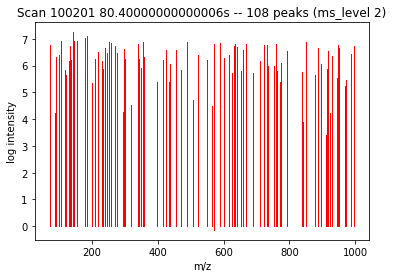

In [22]:
env.render()

Target the next most intense precursor for fragmentation, and generate an MS2 scan

In [23]:
action = 1
observation, reward, done, info = env.step(action)

print('reward', reward)
print('done', done)
scan_df, count_df = obs_to_dfs(observation, env.features)
scan_df, count_df

reward 0.24232656614505843
done False


(    intensities  fragmented  excluded  log_intensities
 0      0.210734         0.2      0.04         9.704642
 1      0.199052         0.2      0.04         9.166694
 2      0.149960         0.0      0.00         6.905936
 3      0.149224         0.0      0.00         6.872039
 4      0.149224         0.0      0.00         6.872036
 ..          ...         ...       ...              ...
 95     0.000000         0.0      0.00         0.000000
 96     0.000000         0.0      0.00         0.000000
 97     0.000000         0.0      0.00         0.000000
 98     0.000000         0.0      0.00         0.000000
 99     0.000000         0.0      0.00         0.000000
 
 [100 rows x 4 columns],
                               counts
 ms_level                      2.0000
 fragmented_count              0.0200
 unfragmented_count            0.9800
 excluded_count                0.0200
 unexcluded_count              0.9800
 elapsed_scans_since_start     0.0203
 elapsed_scans_since_last_ms1  0.02

In [24]:
observation['valid_actions']

array([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 0., 0., 0., 0., 0., 1.],
      dtype=float32)

In [25]:
env.features

[mz=258.4969947671568 rt=80.00000000000006 intensity=16393.53441509632 (0.21073362983682917),
 mz=212.1692703784082 rt=80.00000000000006 intensity=9572.925483394827 (0.19905223391674196),
 mz=203.3435575785719 rt=80.00000000000006 intensity=998.1822232098187 (0.14996049155888208),
 mz=131.61646215107575 rt=80.00000000000006 intensity=964.9144493337008 (0.14922444049468603),
 mz=730.6292779987937 rt=80.00000000000006 intensity=964.9114459916555 (0.14922437290647092),
 mz=833.3944482780043 rt=80.00000000000006 intensity=931.5653551458438 (0.14846066643899067),
 mz=265.4623012097584 rt=80.00000000000006 intensity=916.8899229709659 (0.14811585998329171),
 mz=952.0482781416174 rt=80.00000000000006 intensity=914.3175706727934 (0.14805485328976825),
 mz=770.0441686487587 rt=80.00000000000006 intensity=900.3795408531018 (0.14772128090263298),
 mz=114.95871491960997 rt=80.00000000000006 intensity=896.5061430908033 (0.14762766349029752),
 mz=628.1012851356945 rt=80.00000000000006 intensity=895.4

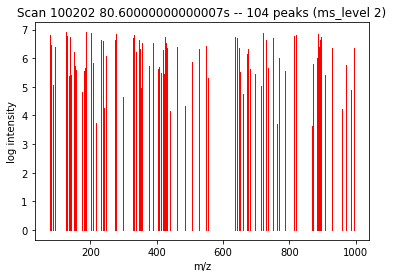

In [26]:
env.render()

Repeat targeting of the same precursor will end up targeting low-intensity spike noises (non-chemicals), which produce no reward

In [27]:
for i in range(10):
    action = 0
    observation, reward, done, info = env.step(action)
    print('reward', reward)
    # print('done', done)
    # pp.pprint(observation)
    # env.render()

reward 0.0
reward 0
reward 0
reward 0
reward 0
reward 0
reward 0
reward 0
reward 0
reward 0


In [28]:
scan_df, count_df = obs_to_dfs(observation, env.features)
scan_df, count_df

(    intensities  fragmented  excluded  log_intensities
 0      0.210734         1.0  0.173333         9.704642
 1      0.199052         0.2  0.173333         9.166694
 2      0.149960         0.0  0.000000         6.905936
 3      0.149224         0.0  0.000000         6.872039
 4      0.149224         0.0  0.000000         6.872036
 ..          ...         ...       ...              ...
 95     0.000000         0.0  0.000000         0.000000
 96     0.000000         0.0  0.000000         0.000000
 97     0.000000         0.0  0.000000         0.000000
 98     0.000000         0.0  0.000000         0.000000
 99     0.000000         0.0  0.000000         0.000000
 
 [100 rows x 4 columns],
                               counts
 ms_level                      2.0000
 fragmented_count              0.0200
 unfragmented_count            0.9800
 excluded_count                0.0200
 unexcluded_count              0.9800
 elapsed_scans_since_start     0.0213
 elapsed_scans_since_last_ms1  0.12

In [29]:
observation['valid_actions']

array([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 0., 0., 0., 0., 0., 1.],
      dtype=float32)

In [30]:
env.features

[mz=258.4969947671568 rt=80.00000000000006 intensity=16393.53441509632 (0.21073362983682917),
 mz=212.1692703784082 rt=80.00000000000006 intensity=9572.925483394827 (0.19905223391674196),
 mz=203.3435575785719 rt=80.00000000000006 intensity=998.1822232098187 (0.14996049155888208),
 mz=131.61646215107575 rt=80.00000000000006 intensity=964.9144493337008 (0.14922444049468603),
 mz=730.6292779987937 rt=80.00000000000006 intensity=964.9114459916555 (0.14922437290647092),
 mz=833.3944482780043 rt=80.00000000000006 intensity=931.5653551458438 (0.14846066643899067),
 mz=265.4623012097584 rt=80.00000000000006 intensity=916.8899229709659 (0.14811585998329171),
 mz=952.0482781416174 rt=80.00000000000006 intensity=914.3175706727934 (0.14805485328976825),
 mz=770.0441686487587 rt=80.00000000000006 intensity=900.3795408531018 (0.14772128090263298),
 mz=114.95871491960997 rt=80.00000000000006 intensity=896.5061430908033 (0.14762766349029752),
 mz=628.1012851356945 rt=80.00000000000006 intensity=895.4

Making an invalid move produces negative reward.

In [31]:
action = 50 # no precursor to fragment at this index
observation, reward, done, info = env.step(action)

print('reward', reward)
print('done', done)
scan_df, count_df = obs_to_dfs(observation, env.features)
scan_df, count_df

reward 0
done False


(    intensities  fragmented  excluded  log_intensities
 0      0.210734         1.0  0.186667         9.704642
 1      0.199052         0.2  0.186667         9.166694
 2      0.149960         0.0  0.000000         6.905936
 3      0.149224         0.0  0.000000         6.872039
 4      0.149224         0.0  0.000000         6.872036
 ..          ...         ...       ...              ...
 95     0.000000         0.0  0.000000         0.000000
 96     0.000000         0.0  0.000000         0.000000
 97     0.000000         0.0  0.000000         0.000000
 98     0.000000         0.0  0.000000         0.000000
 99     0.000000         0.0  0.000000         0.000000
 
 [100 rows x 4 columns],
                               counts
 ms_level                      2.0000
 fragmented_count              0.0300
 unfragmented_count            0.9700
 excluded_count                0.0300
 unexcluded_count              0.9700
 elapsed_scans_since_start     0.0214
 elapsed_scans_since_last_ms1  0.13

In [32]:
observation['valid_actions']

array([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 0., 0., 0., 0., 0., 1.],
      dtype=float32)

In [33]:
env.features

[mz=258.4969947671568 rt=80.00000000000006 intensity=16393.53441509632 (0.21073362983682917),
 mz=212.1692703784082 rt=80.00000000000006 intensity=9572.925483394827 (0.19905223391674196),
 mz=203.3435575785719 rt=80.00000000000006 intensity=998.1822232098187 (0.14996049155888208),
 mz=131.61646215107575 rt=80.00000000000006 intensity=964.9144493337008 (0.14922444049468603),
 mz=730.6292779987937 rt=80.00000000000006 intensity=964.9114459916555 (0.14922437290647092),
 mz=833.3944482780043 rt=80.00000000000006 intensity=931.5653551458438 (0.14846066643899067),
 mz=265.4623012097584 rt=80.00000000000006 intensity=916.8899229709659 (0.14811585998329171),
 mz=952.0482781416174 rt=80.00000000000006 intensity=914.3175706727934 (0.14805485328976825),
 mz=770.0441686487587 rt=80.00000000000006 intensity=900.3795408531018 (0.14772128090263298),
 mz=114.95871491960997 rt=80.00000000000006 intensity=896.5061430908033 (0.14762766349029752),
 mz=628.1012851356945 rt=80.00000000000006 intensity=895.4

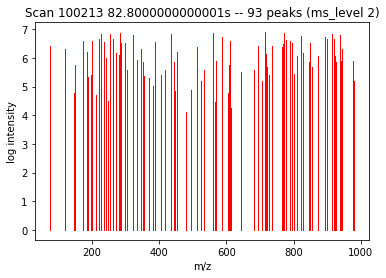

In [34]:
env.render()

Generate lots of MS1 scans

In [35]:
for i in range(100):
    action = max_peaks # ms1
    observation, reward, done, info = env.step(action)

print('reward', reward)
print('done', done)
scan_df, count_df = obs_to_dfs(observation, env.features)
scan_df, count_df

reward -0.1
done False


(    intensities  fragmented  excluded  log_intensities
 0      0.214777         0.0       0.0         9.890836
 1      0.149547         0.0       0.0         6.886893
 2      0.149428         0.0       0.0         6.881414
 3      0.149219         0.0       0.0         6.871784
 4      0.149013         0.0       0.0         6.862307
 ..          ...         ...       ...              ...
 95     0.000000         0.0       0.0         0.000000
 96     0.000000         0.0       0.0         0.000000
 97     0.000000         0.0       0.0         0.000000
 98     0.000000         0.0       0.0         0.000000
 99     0.000000         0.0       0.0         0.000000
 
 [100 rows x 4 columns],
                               counts
 ms_level                      1.0000
 fragmented_count              0.0000
 unfragmented_count            1.0000
 excluded_count                0.0000
 unexcluded_count              1.0000
 elapsed_scans_since_start     0.0314
 elapsed_scans_since_last_ms1  0.00

In [36]:
observation['valid_actions']

array([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 0., 0., 0., 0., 0., 0., 1.],
      dtype=float32)

In [37]:
env.features

[mz=74.26500527177687 rt=122.60000000000066 intensity=19748.566125927813 (0.2147767784254565),
 mz=913.3119917129128 rt=122.60000000000066 intensity=979.3542643564978 (0.14954699093462123),
 mz=921.6548533523909 rt=122.60000000000066 intensity=974.0022814065541 (0.1494279987064111),
 mz=389.68503592749914 rt=122.60000000000066 intensity=964.6679379971263 (0.14921889222089962),
 mz=142.4001089983766 rt=122.60000000000066 intensity=955.5686709218443 (0.1490130951310788),
 mz=411.0161559845335 rt=122.60000000000066 intensity=953.6585397098937 (0.1489696451049518),
 mz=646.9970274202469 rt=122.60000000000066 intensity=946.7433382202496 (0.1488116128940602),
 mz=747.1362845176311 rt=122.60000000000066 intensity=944.2373412055487 (0.14875405856132023),
 mz=177.77805413879958 rt=122.60000000000066 intensity=936.670971993932 (0.14857935306935505),
 mz=463.21067438216664 rt=122.60000000000066 intensity=927.2464787876426 (0.14835975963866813),
 mz=291.3817835334511 rt=122.60000000000066 intensit

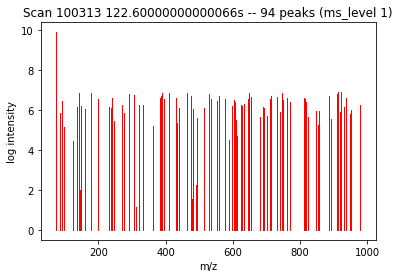

In [38]:
env.render()